In [1]:
import numpy as np
import pandas as pd

In [37]:
data = [['john', 25,65], ['ram', 15,45],['lucky',45,80], ['bob',30]]
df = pd.DataFrame(data, columns=['Name', 'Age', 'Weight'])
df

,Name,Age,Weight
0,john,25,65.0
1,ram,15,45.0
2,lucky,45,80.0
3,bob,30,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    4 non-null      object 
 1   Age     4 non-null      int64  
 2   Weight  3 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 228.0+ bytes


In [6]:
df.isnull()

,Name,Age,Weight
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,True


In [7]:
df.isnull().sum()

Name      0
Age       0
Weight    1
dtype: int64

how to handle the null values
1. drop the entire row
2. replace null with mean, median, mode or something else

In [8]:
df1 = df.dropna();
df1

,Name,Age,Weight
0,john,25,65.0
1,ram,15,45.0
2,lucky,45,80.0


In [12]:
df2 = df
df2['Weight'] = df2['Weight'].fillna(df2['Weight'].mean())
df2

,Name,Age,Weight
0,john,25,65.000000
1,ram,15,45.000000
2,lucky,45,80.000000
3,bob,60,63.333333


In [21]:
from sklearn.impute import SimpleImputer

In [23]:
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean') #create object with constructor

In [25]:
imputer = imputer.fit(df[['Weight']])


In [26]:
df['Weight'] = imputer.transform(df[['Weight']])
df

,Name,Age,Weight
0,john,25,65.000000
1,ram,15,45.000000
2,lucky,45,80.000000
3,bob,60,63.333333


In [32]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [33]:
df

,Name,Age,Weight
0,john,25,65.0
1,ram,15,45.0
2,lucky,45,80.0
3,bob,60,65.0


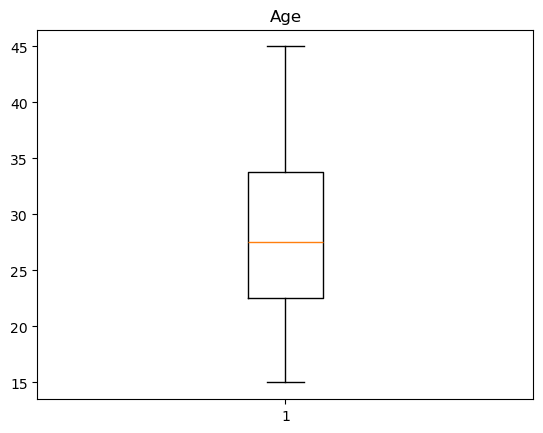

In [38]:
import matplotlib.pyplot as plt
plt.boxplot(df['Age'])
plt.title('Age')
plt.show()

Handling categorical variables
Types of categorical data

Nominal – categories with no order

Example: Colors, Country, Car brand

Ordinal – categories with a meaningful order

Example: Small, Medium, Large

Education level (High School → Bachelor → Master)

✅ Short definition:
Categorical data is data that represents categories or labels instead of numerical values.

In [47]:
data = {
    'Color': ['Red', 'Blue', 'Red', 'black'],
    'Size': ['M', 'L', 'S', 'M'],
    'Price': [25, 30, 20, 50]
}

df = pd.DataFrame(data)
df

,Color,Size,Price
0,Red,M,25
1,Blue,L,30
2,Red,S,20
3,black,M,50


In [48]:
df['Size'] = df['Size'].replace({'S':1, 'M':2, 'L':3}) # can use map also
#df['Size'] = df['Size'].map({'S':1, 'M':2, 'L':3}) 
df

C:\Users\gmahe\AppData\Local\Temp\ipykernel_11456\3706896188.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Size'] = df['Size'].replace({'S':1, 'M':2, 'L':3}) # can use map also


,Color,Size,Price
0,Red,2,25
1,Blue,3,30
2,Red,1,20
3,black,2,50


In [49]:
df_encoded = pd.get_dummies(df)
df_encoded

,Size,Price,Color_Blue,Color_Red,Color_black
0,2,25,False,True,False
1,3,30,True,False,False
2,1,20,False,True,False
3,2,50,False,False,True


pd.get_dummies() is good for small or moderate datasets, but it can become inefficient when the number of categories is very large because it creates many extra columns.

Quick rule used in industry
# Categories	Recommended Encoding
< 20	One-Hot (get_dummies)
20 – 100	Consider Label / Frequency
100+	Target / Hash encoding

Variables Type	in ML Description	Example
Continuous	Any numeric value	Height, Price
Discrete	Count numbers	Number of orders
Nominal	Categories with no order	Color
Ordinal	Categories with order	Size (S,M,L)
Binary	Two categories	Yes/No